# Score Differences - Smoke Test

In the original `score_differences.ipynb` notebook we saw a bi-modal distribution of "rag effects". Would we get a bi-modal distribution comparing any two runs? Is it just a side-effect of a scoring system where it's a lot easier to change your score by 5-7 points than it is to change it by 1?

In [ ]:
from pathlib import Path

import polars as pl
import seaborn as sns

from simple_evals.improvement.models.results import AllResults

In [2]:
baseline_results_path = Path(
    "/Users/max/Developer/repos/HealthBench/results/5df4ba309cb03369f6663786ae6a9904385524a9/"
    + "maverick/healthbench_llama-4-maverick_20251023_212754_allresults.json"
)
baseline_results = AllResults.from_file(baseline_results_path)


In [4]:
second_run_dir = Path(
    "/Users/max/Developer/repos/HealthBench/results/5df4ba309cb03369f6663786ae6a9904385524a9/maverick"
)
second_results_path = (
    second_run_dir / "healthbench_llama-4-maverick_20251027_153644_allresults.json"
)
second_results = AllResults.from_file(second_results_path)

In [5]:
def flatten_metadata(results: AllResults, model_name: str) -> list[dict]:
    """
    Flattens the 'example_level_metadata' objects from the benchmark results file.
    """
    out = []
    for metadata in results.metadata.example_level_metadata:
        out.append(
            {
                "prompt_id": metadata.prompt_id,
                f"score_{model_name}": metadata.score,
            }
        )
    return out

In [7]:
baseline = pl.DataFrame(flatten_metadata(baseline_results, "baseline"))
second = pl.DataFrame(flatten_metadata(second_results, "second"))

In [8]:
combined = baseline.join(second, on="prompt_id")
combined.head()

prompt_id,score_baseline,score_second
str,f64,f64
"""1f548d5b-cd00-49a0-b327-283a2e…",0.637363,0.67033
"""0b8f1d60-2081-4562-98f7-b6a976…",0.338983,0.305085
"""6f7a2ee9-e9c6-42d8-b79f-22dea9…",1.0,0.5
"""19ec4833-86e9-4166-8b82-d1da09…",0.469136,0.358025
"""7ebc830a-8dbd-489b-9d61-4d8bac…",0.257143,0.157143


In [9]:
sns.set_style("whitegrid")

In [11]:
diffs = combined.with_columns(
    # Calculate the difference between the runs for each question
    (pl.col("score_second") - pl.col("score_baseline")).alias("effect_of_second"),
    # Calculate the difference between the runs for each question
    (
        pl.when((pl.col("score_second") - pl.col("score_baseline") > 0))
        .then(pl.lit("better"))
        .otherwise(pl.lit("worse"))
    ).alias("better_or_worse"),
)

(-1.2, 1.2)

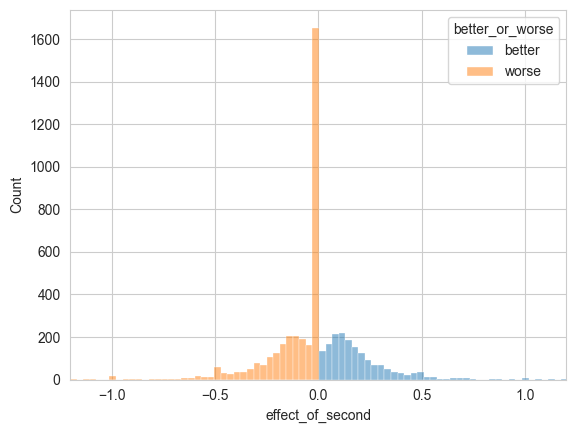

In [12]:
g = sns.histplot(diffs, x="effect_of_second", hue="better_or_worse")
g.set_xlim(-1.2, 1.2)

(-1.2, 1.2)

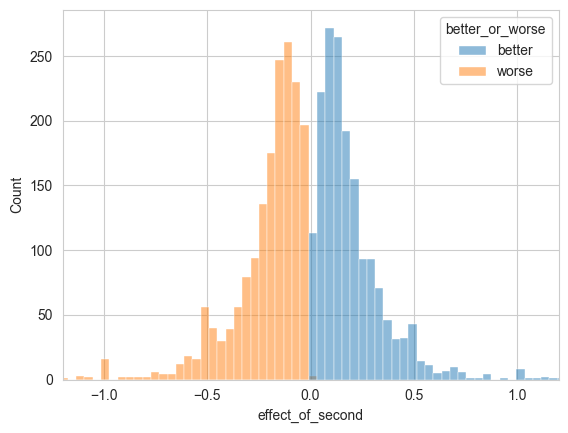

In [13]:
g = sns.histplot(
    diffs.filter(pl.col("effect_of_second") != 0),
    x="effect_of_second",
    hue="better_or_worse",
)
g.set_xlim(-1.2, 1.2)

So, it looks like the bi-modal distribution probably is due to the fact that a model is more likely to change its score on a question by 5-7 than it is by 1-2.

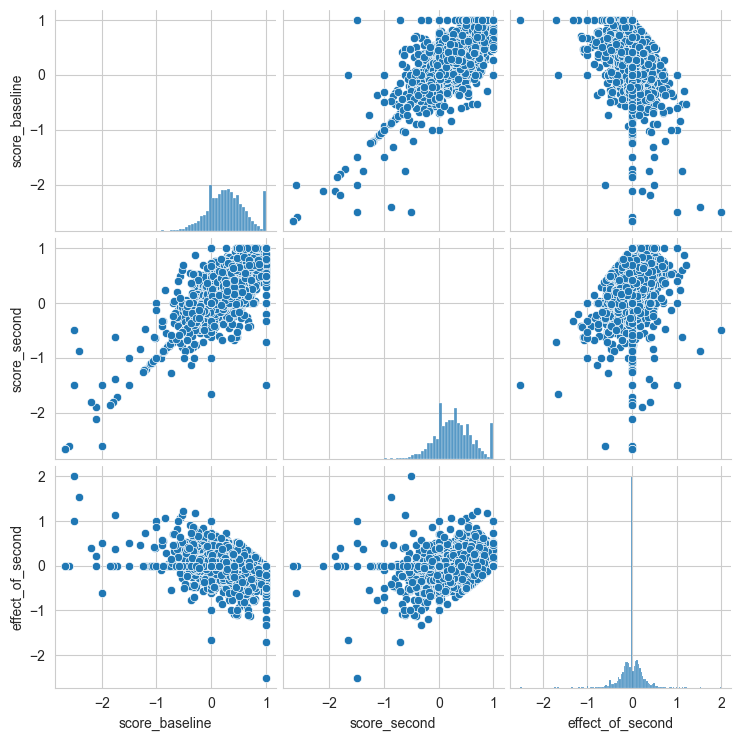

In [15]:
# What does the relationship look like between the baseline score, the rag
# score, and the difference between them?
sns.pairplot(
    diffs.select("score_baseline", "score_second", "effect_of_second").to_pandas()
)